## Daniel Peña Fonseca. 20031020-T330

Use of LLMs (ChatGPT) for this exercise:
- Common use: Used for most exercises for debugging and to do plots faster. Also, it was specially helpful to figure out how to guarantee the same randomness applied in Ex 4.3. to see the same results for Ex 4.5. using rng=random.Random(seed); this is however not relevant for the exercise's performance.
- Exercise 4.1: LLM was used to corrrectly scale the mnist data (np.float32). It was used to familiarize with tensorflow library, since I did not know anything about this module. This was particularly useful for the training: model.compile, model.fit, and the use of a checkpoint to guarantee keeping the model with maximum validation accuracy. 
- Exercise 4.2: Again, it was used to familiarize with the way in which I can see what probabilities the model assigns to each of the classes; i.e. model.predict. Therefore, it was used for functions probability_of_true_class and class_probabilities. 
- Exercise 4.3: Since this exercise used the functions probability_of_true_class and class_probabilities, and those were created with the help of an LLM, one could argue that it was helpful for this exercise.
- Exercise 4.4: Extensively used for this exercise, given that the study of the gradient has to be done using the tensorflow library, like GradientTape, which I did not know about. Also, managing a tensor was new for me, so the LLM was also helpful with it.

# Exercise 4

In [1]:
%pip install numpy matplotlib tensorflow scikit-learn -q

Note: you may need to restart the kernel to use updated packages.


In [111]:
import numpy as np
import math
from matplotlib import pyplot as plt
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models
from sklearn.neighbors import KNeighborsClassifier
import statistics
import copy
from collections import Counter
import random

# Exercise 4.1

The downloading and training of the model is done as in Assignment 2: we first normalize the data using min-max scaling, and then design a model using the architecture that was suggested.

In [4]:
# Load MNIST data
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# min-max scaling. 
# float32 to avoid problems with the original types of the mnist data
# We use copy.deepcopy because otherwise, we could be scaling incorrectly if repeatedly running this jupyter cell
print(f'The shape of MNIST data is: {x_train_mnist.shape}')
x_train_mnist_scaled = copy.deepcopy(x_train_mnist.astype(np.float32) / 255.0)
x_test_mnist_scaled = copy.deepcopy(x_test_mnist.astype(np.float32) / 255.0)

print('After scaling MNIST:')
print(f' Minimum value: {x_train_mnist_scaled.min():.3f}')
print(f' Maximum value: {x_train_mnist_scaled.max():.3f}')

The shape of MNIST data is: (60000, 28, 28)
After scaling MNIST:
 Minimum value: 0.000
 Maximum value: 1.000


In [10]:
# Set up
mnist_model = models.Sequential([
    # First Convolutional Block: 1st & 2nd layer
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)), # 1st layer - conv. layer with 16-64 filters (3x3), ReLU activation & batch normalization
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), # 2nd layer - Max pooling (2x2)

    # Second Convolutional Block: 2nd & 3rd layer
    layers.Conv2D(64, (3,3), activation = 'relu'), # 3rd layer - Convolution layer with 32-128 filters (3x3), ReLU activation, and batch normalization
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), # 4th layer - Max pooling (2x2)
    
    # Classifier Head: Flatten + 4th & 5th layer
    layers.Flatten(), 
    layers.Dense(128, activation='relu'), # 5th layer - Fully connected dense layer with 128 neurons, ReLU (dropout during training, dropout range (somewhere [0.2, 0.5])
    layers.Dropout(0.3),
    layers.Dense(10, activation = 'softmax') # Sixth layer - A layer wit 10 neurons (=the number of classes) and a softmax activation function
    
])


# Training
mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] 
)

checkpoint = ModelCheckpoint(
    filepath="Assignment_4/best_mnist_model.keras",
    monitor="val_accuracy",
    save_best_only=True, # We keep the model at the epoch where we get maximum validation accuracy
    mode="max",
    verbose=1
)

history = mnist_model.fit(
    x_train_mnist_scaled,
    y_train_mnist,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint]
)

Epoch 1/20
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8936 - loss: 0.3575
Epoch 1: val_accuracy improved from None to 0.98342, saving model to /Users/daniel/Desktop/Interpretable AI (IAI)/Programming/Exercise_4/best_mnist_model.keras

Epoch 1: finished saving model to /Users/daniel/Desktop/Interpretable AI (IAI)/Programming/Exercise_4/best_mnist_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9472 - loss: 0.1732 - val_accuracy: 0.9834 - val_loss: 0.0558
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9805 - loss: 0.0677
Epoch 2: val_accuracy did not improve from 0.98342
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9808 - loss: 0.0673 - val_accuracy: 0.9824 - val_loss: 0.0614
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9852 - loss: 0.0493
Epoch 3: val_accuracy improved from 0.98342 to 0.98683, saving model to /Users/daniel/Desktop/Interpretable AI (IAI)/Programming/Exercise_4/best_mnist_model.keras

Ep

In [102]:
# Download the model from another file
best_mnist_model = load_model("Assignment_4/best_mnist_model.keras")

# Test loss and test accuracy
test_loss, test_accuracy = best_mnist_model.evaluate(x_test_mnist_scaled, y_test_mnist)
print(f"Test loss: {test_loss:.4f}. Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9923 - loss: 0.0456
Test loss: 0.0456. Test accuracy: 0.9923


For the following, I will create a function for each of the methods studied. This will keep the code clean when studying the effect of the attacks and generating the plots.
All of the methods have some inputs in common. They all need the trained model, the test images, the test labels, and the index of the image under study.

# Exercise 4.2

## Brute-force black-box attack: Greedy random search

Description of the process: Let's say we have an image I, belonging to the class $C_I$, the idea behind this type of attack is to make progressive changes in the image $I$ until we obtain an image $I'$ that our model no longer classifies as $C_I$.

For this, we will make use of our trained model. With our trained model we can study what probability does the model assign to the image belonging to each possible class. We calculate these probabilities before ($p_{\text{before}}$) and after making the change ($p_{\text{after}}$). If the change is 'benefitial', we actually make the change; if not, we keep the last image. For this type of attacks, we consider that a change is benefitial when, after the change, the model considers less probable that the image belongs to class $C_I$, than before; i.e. $p_{\text{before}}(C_I)>p_{\text{after}}(C_I)$. 

Following this procedure, we progressively change the image until we obtain a final image that our model no longer classifies as $C_I$; i.e. the model assigns the highest probability to a class that is not $C_I$.

Other inputs needed for the function apart from those common to all attack functions: Here, we must indicate the maximum number of times that we can apply salt-pepper noise and the fraction of pixels that we modify in each change applied.

In [207]:

def probability_of_true_class(model, image, true_label):
    probs = model.predict(image[np.newaxis, ...], verbose=0)[0]
    return probs[true_label]

def class_probabilities(model, image):
    return model.predict(image[np.newaxis, ...], verbose=0)[0]

def brute_force_black_box_attack(image_i_index, maximum_number_of_changes, fraction_of_pixels_changed, model, test_images, test_labels, rng):
    "Brute-force black box attack"

    # Greedy random search
    # random.seed(88)
    # number_of_studied_images = 12
    number_of_rows = len(test_images[0])
    number_of_columns = len(test_images[0,0])
    number_of_pixels_changed = int((number_of_rows * number_of_columns)*fraction_of_pixels_changed)

    number_of_changes = 0

    # print(f'Shape of each image: {x_test_mnist_scaled[0].shape}')

    print('Brute-force Black-box attack:')
    #print('    Number of changes needed for misclassification:')
    # for i in range(number_of_studied_images):
    i = image_i_index
    test_image = test_images[i]
    true_label = test_labels[i]
    new_image = copy.deepcopy(test_image)

    for j in range(maximum_number_of_changes):
        previous_image = copy.deepcopy(new_image)
        old_classification = probability_of_true_class(best_mnist_model, previous_image, true_label)

        # Salt-pepper noise
        for k in range(number_of_pixels_changed):
            random_row = rng.randint(0,number_of_rows-1)
            random_column = rng.randint(0,number_of_columns-1)
            new_image[random_row, random_column] = rng.randint(0,1) 
        
        # Correct class probability for image after new salt-pepper noise change
        new_classification = probability_of_true_class(model, new_image, true_label) 
        if new_classification > old_classification:
            # Higher probability to the correct class for the new image => we keep previous image
            new_image = previous_image
        else:
            number_of_changes +=1
            
        predicted_label = np.argmax(class_probabilities(model, new_image)) # Predicted class = class with highest probability
        if predicted_label != true_label:
            # We stop changing the image once it is misclassified
            print(f'    Misclassification after {number_of_changes} changes of {fraction_of_pixels_changed*100:.0f}% pixels each. Prediction: {predicted_label}')
            break

    if predicted_label == true_label:
        print(f'    No miscalssification managed after {number_of_changes} changes of {fraction_of_pixels_changed*100:.0f}% pixels each.')

    return j, predicted_label, new_image



Shape of each image: (28, 28)
Test image index 3336. Label: 5
Brute-force Black-box attack:
    Misclassification after 4 changes of 5% pixels each. Prediction: 4


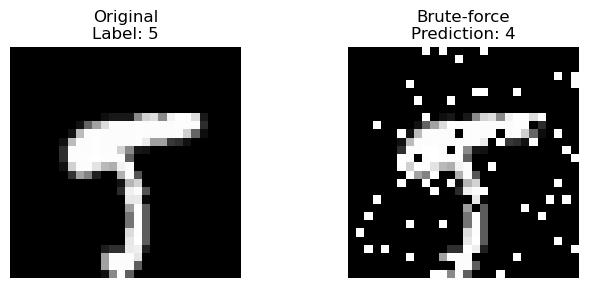

Test image index 1518. Label: 2
Brute-force Black-box attack:
    Misclassification after 5 changes of 5% pixels each. Prediction: 8


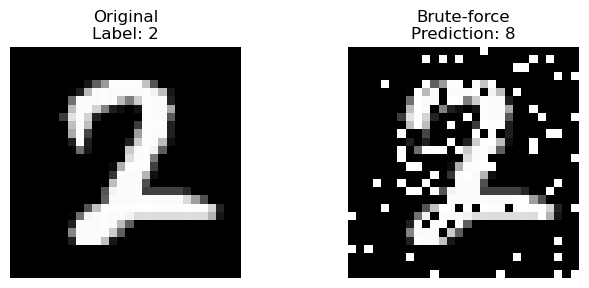

Test image index 7881. Label: 1
Brute-force Black-box attack:
    Misclassification after 3 changes of 5% pixels each. Prediction: 7


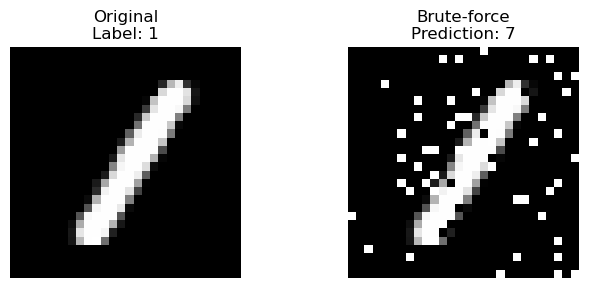

Test image index 9414. Label: 0
Brute-force Black-box attack:
    Misclassification after 5 changes of 5% pixels each. Prediction: 2


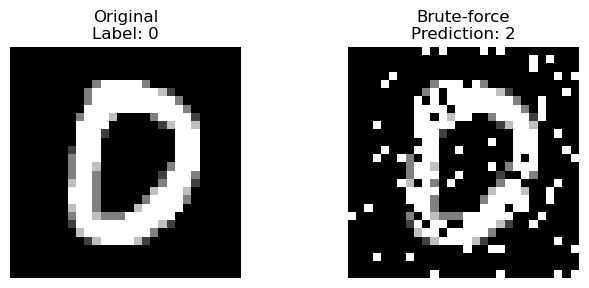

Test image index 9603. Label: 2
Brute-force Black-box attack:
    Misclassification after 7 changes of 5% pixels each. Prediction: 8


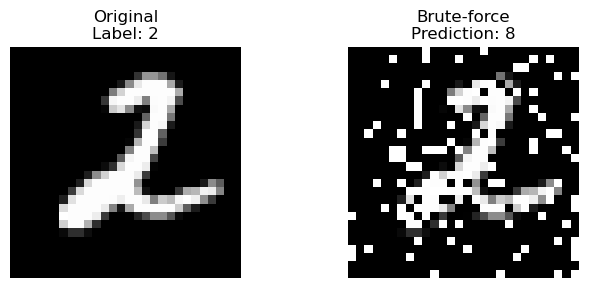

Test image index 5075. Label: 8
Brute-force Black-box attack:
    Misclassification after 6 changes of 5% pixels each. Prediction: 3


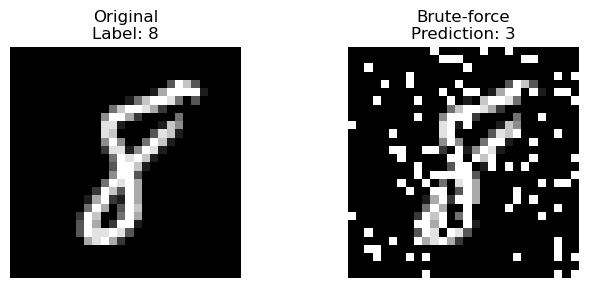

Test image index 5813. Label: 9
Brute-force Black-box attack:
    Misclassification after 5 changes of 5% pixels each. Prediction: 4


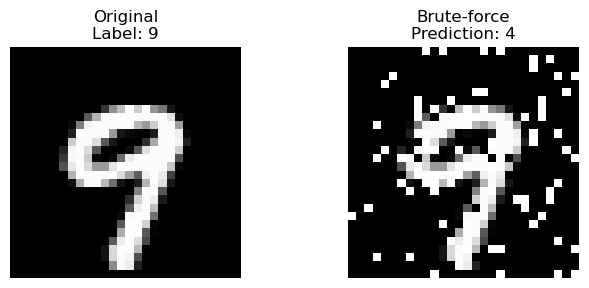

In [222]:
# Greedy random search
random.seed(90)
rng = random.Random(99)
number_of_studied_images = 7
maximum_number_of_changes = 20
fraction_of_pixels_changed = 5/100

print(f'Shape of each image: {x_test_mnist_scaled[0].shape}')

for _ in range(number_of_studied_images):

    image_index_i = random.choice(range(len(x_test_mnist_scaled)))
    i = image_index_i
    test_image_i = x_test_mnist_scaled[i]
    test_image_i_label = y_test_mnist[i]

    print(f'Test image index {i}. Label: {test_image_i_label}')
    
    plt.figure(figsize=(8, 3))
    number_of_figure_rows = 1
    number_of_figure_columns = 2

    rng = random.Random(99)
    j_brute, brute_predicted_label, final_image_i_brute = brute_force_black_box_attack(image_index_i, maximum_number_of_changes, fraction_of_pixels_changed, best_mnist_model, x_test_mnist_scaled, y_test_mnist, rng)

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 1)
    plt.imshow(test_image_i, cmap="gray")
    plt.title(f"Original\nLabel: {test_image_i_label}") # \n At most {j_brute+1} changes of {fraction_of_pixels_changed*100:.0f}% pixels each.")
    plt.axis("off")

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 2)
    plt.imshow(final_image_i_brute, cmap="gray")
    plt.title(f"Brute-force\nPrediction: {brute_predicted_label}") # \n At most {j_brute+1} changes of {fraction_of_pixels_changed*100:.0f}% pixels each.")
    plt.axis("off")

    plt.show()


# Exercise 4.3

## Boundary attack:
Description of the process: Let's say we have an image I, belonging to the class $C_I$, and an image T, belonging to the class $C_T$; the idea behind this type of attack is to make progressive tweaks in the image I for it to be closer to image T.

Using our trained model, we calculate the probabilities assigned before, $p_{\text{before}}$, and after making each change, $p_{\text{after}}$. If the change is 'benefitial', we actually make the change; if not, we keep the last image. For this type of attacks, we consider a change benefitial if, after the change, the model still classifies that the image belongs to class $C_I$, but the probability that the model assigns to the image being part of class $C_T$ increases.

Following this procedure, we progressively change the image I until it resembles image T as much as possible, but is still classified as $C_I$. This way, we explore the boundary of classification.

Other inputs needed apart from those common to all attack functions: Here, we must indicate the maximum number of tweaks that we can apply to the image and the fraction of pixels that we change in each tweak applied.

In [216]:

def boundary_black_box_attack(image_index_i, image_index_j, fraction_of_different_pixels_change, maximum_number_of_tweaks, model, test_images, test_labels, rng):

    
    i = image_index_i
    j = image_index_j

    test_image_t = copy.deepcopy(test_images[i])
    test_image_i = copy.deepcopy(test_images[j])

    test_image_t_label = test_labels[i]
    test_image_i_label = test_labels[j]

    initial_test_image_i = copy.deepcopy(test_image_i)
    initial_classification_probabilities = class_probabilities(model, initial_test_image_i)
    final_probability_of_class_i = initial_classification_probabilities[test_image_i_label]
    final_probability_of_class_t = initial_classification_probabilities[test_image_t_label]

    number_of_tweaks = 0

    # while (difference > tolerance) or (i==maximum_number_of_tweaks):
    for _ in range(maximum_number_of_tweaks):

        # Step 1 - Compute the probabilities assigned by the model to each class
        old_classification_probabilities = class_probabilities(model, test_image_i)
        old_probability_of_class_t = old_classification_probabilities[test_image_t_label]
        
        # We compute the difference between the images, and the non-zero value pixels will be tweaked (some fraction of them) from the value that they had in image I
        # to the value that the have in image T
        matrix_difference = test_image_t - test_image_i 
        non_zero_rows, non_zero_columns = np.nonzero(matrix_difference)
        provisional_non_zero_rows, provisional_non_zero_columns = np.nonzero(matrix_difference)
        changing_rows, changing_columns = [], []
        number_of_pixel_tweaks = int(len(non_zero_rows)*fraction_of_different_pixels_change)
        #print(len(non_zero_rows))
        

        # Step 2 - We only select a fraction of the pixels with different values in image I than image T to change
        for _ in range(number_of_pixel_tweaks):

            index = rng.choice(list(range(len(provisional_non_zero_rows))))
            changing_rows.append(provisional_non_zero_rows[index])
            changing_columns.append(provisional_non_zero_columns[index])
            provisional_non_zero_rows = np.delete(provisional_non_zero_rows, index)
            provisional_non_zero_columns = np.delete(provisional_non_zero_columns, index)
            #provisional_non_zero_rows.pop(index)
            #provisional_non_zero_columns.pop(index)


        # Step 3 - We change the selected pixels generating a provisional image
        provisional_test_image_i = copy.deepcopy(test_image_i)
        for row, column in zip(changing_rows, changing_columns):
            provisional_test_image_i[row, column] = test_image_t[row, column]

        # We compute the probabilities that the model assigns to each class for the provisional image
        new_classification_probabilities = class_probabilities(model, provisional_test_image_i)
        predicted_label = np.argmax(new_classification_probabilities) # Predicted class = class with highest probability
        new_probability_of_class_t = new_classification_probabilities[test_image_t_label]

        # First: See if class I still has the highest probability. Otherwise, break (no change applied to image)
        if predicted_label != test_image_i_label:
            continue

        # Second: See if class T has more probability than before. Otherwise, break (no change applied to image)
        if new_probability_of_class_t < old_probability_of_class_t:
            continue
        # Although this second condition is not specified in the statement, I set it because it seems helpful for studying the boundary between
        # class I and class T. Otherwise, we could be moving towards anoter image. However, this consideration might not be very useful, since
        # tweaking the image I in the direction of T will likely increase the probability of classifying it as T.
        
        number_of_tweaks += 1
        test_image_i = copy.deepcopy(provisional_test_image_i)
        final_probability_of_class_t = new_probability_of_class_t
        final_probability_of_class_i = new_classification_probabilities[test_image_i_label]

    print('Boundary attack:')
    print(f'    Initial probability of I classified as I: {initial_classification_probabilities[test_image_i_label]:.2f}.')
    #print(f'Initial probability of I classified as T: {initial_classification_probabilities[test_image_t_label]:.2f}.')
    print(f'    After {number_of_tweaks} tweaks of {fraction_of_different_pixels_change*100:.0f}% pixels each:')
    print(f'    Probability of being classified as I: {final_probability_of_class_i:.2f}')
    print(f'    Probability of being classified as T: {final_probability_of_class_t:.2f}')

    return j, test_image_i, final_probability_of_class_i, final_probability_of_class_t


Image I: Index 1518. Label 2
Image T: Index 3336. Label 5
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 15 tweaks of 5% pixels each:
    Probability of being classified as I: 0.43
    Probability of being classified as T: 0.16


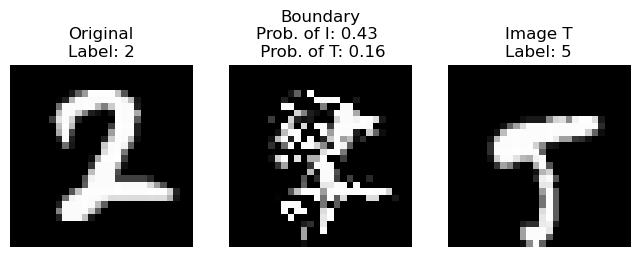

Image I: Index 9414. Label 0
Image T: Index 7881. Label 1
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 7 tweaks of 5% pixels each:
    Probability of being classified as I: 0.34
    Probability of being classified as T: 0.01


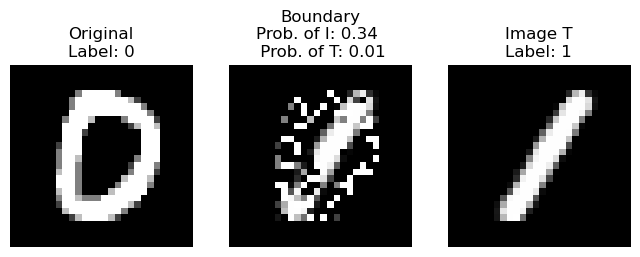

Image I: Index 5075. Label 8
Image T: Index 9603. Label 2
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 14 tweaks of 5% pixels each:
    Probability of being classified as I: 0.56
    Probability of being classified as T: 0.44


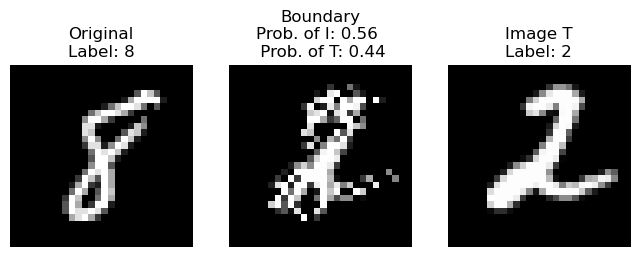

Image I: Index 7393. Label 5
Image T: Index 5813. Label 9
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 10 tweaks of 5% pixels each:
    Probability of being classified as I: 0.51
    Probability of being classified as T: 0.49


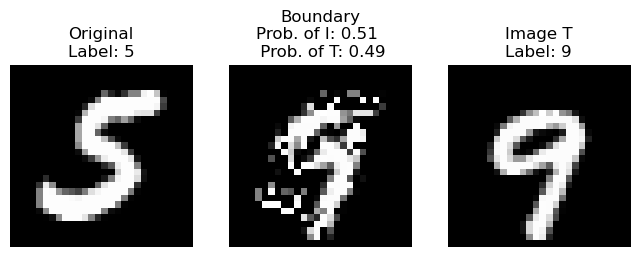

Image I: Index 8001. Label 9
Image T: Index 4337. Label 1
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 7 tweaks of 5% pixels each:
    Probability of being classified as I: 0.47
    Probability of being classified as T: 0.00


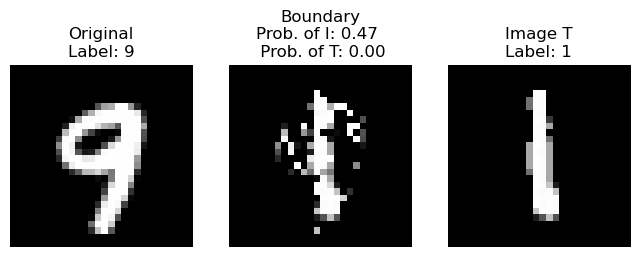

Image I: Index 6058. Label 1
Image T: Index 4470. Label 0
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 17 tweaks of 5% pixels each:
    Probability of being classified as I: 0.31
    Probability of being classified as T: 0.15


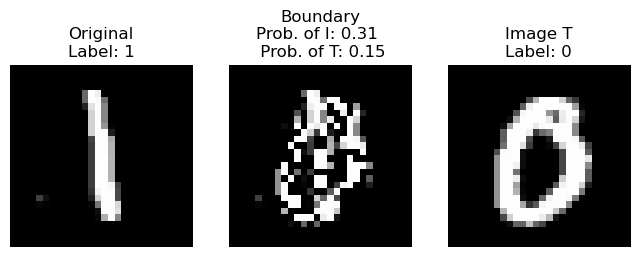

In [220]:
random.seed(90)

number_of_i_images = 7

fraction_of_different_pixels_change = 5/100
maximum_number_of_tweaks = 100

for _ in range(number_of_i_images):
            
    i = random.choice(range(len(x_test_mnist_scaled)))
    j = random.choice(range(len(x_test_mnist_scaled)))

    image_index_t = i
    image_index_i = j

    test_image_t = x_test_mnist_scaled[i]
    test_image_i = x_test_mnist_scaled[j]

    test_image_t_label = y_test_mnist[i] 
    test_image_i_label = y_test_mnist[j] 

    # We ensure that they are different
    if test_image_i_label == test_image_t_label:
        continue

    plt.figure(figsize=(8, 3))
    number_of_figure_rows = 1
    number_of_figure_columns = 3
    
    print(f'Image I: Index {j}. Label {test_image_i_label}')
    print(f'Image T: Index {i}. Label {test_image_t_label}')

    rng = random.Random(99)
    # We compute the process
    j_boundary, final_image_i_boundary, final_probability_of_class_i, final_probability_of_class_t = boundary_black_box_attack(image_index_i, image_index_t, fraction_of_different_pixels_change, maximum_number_of_tweaks, best_mnist_model, x_test_mnist_scaled, y_test_mnist, rng)

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 1)
    plt.imshow(test_image_i, cmap="gray")
    plt.title(f"Original\nLabel: {test_image_i_label:.0f}")
    plt.axis("off")

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 2)
    plt.imshow(final_image_i_boundary, cmap="gray")
    plt.title(f"Boundary\nProb. of I: {final_probability_of_class_i:.2f} \n Prob. of T: {final_probability_of_class_t:.2f}")
    plt.axis("off")

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 3)
    plt.imshow(test_image_t, cmap="gray")
    plt.title(f"Image T\nLabel: {test_image_t_label}")
    plt.axis("off")

    plt.show()

# Exercise 4.4

## Fast gradient sign method (FSGM)
Other inputs: We must indicate the epsilon in $x_{\text{adv}} = x + \varepsilon \, \text{sign}(\nabla_x J(\theta, x, y))$.
Description of the process: Let's say we have an image I, belonging to the class $C_I$; the idea behind this type of attack is to make only one change in the image in the direction of the maximum loss function.

Using a value of $\varepsilon$ big enough (although not that big), we will noticeably modify the original image towards the pixel-change direction that maximizes the odds of misclassification. 

Other inputs needed apart those common to all attack functions: Here, we must indicate the epsilon in $x_{\text{adv}} = x + \varepsilon \, \text{sign}(\nabla_x J(\theta, x, y))$.

In [233]:
import tensorflow

def fast_gradient_sign_method(image_i_index, epsilon, model, test_images, test_labels):
    index = image_i_index

    x = test_images[index]
    y = test_labels[index]

    # (batch, height, width, channels) = (1, 28, 28, 1)
    x_input = x[np.newaxis, ..., np.newaxis]

    # We convert to tensor so we can study the gradient
    x_tensor = tensorflow.convert_to_tensor(x_input, dtype=tensorflow.float32)

    with tensorflow.GradientTape() as tape:
        tape.watch(x_tensor)  # We now track the gradients from the image

        predictions = model(x_tensor) # Probability distribution over digits

        # Now we compute the loss by checking the actual class of x with the prediction
        loss = tensorflow.keras.losses.sparse_categorical_crossentropy(
        tensorflow.constant([y]),
            predictions
        )

    gradient = tape.gradient(loss, x_tensor)
    signed_gradient = tensorflow.sign(gradient)
    
    x_adv = x_tensor + epsilon * signed_gradient
    x_adv = tensorflow.clip_by_value(x_adv, 0.0, 1.0)


    original_prediction = np.argmax(model(x_tensor)[0]) # Index of highest probability = class
    adversarial_prediction = np.argmax(model(x_adv)[0]) # Index of highest probability = class

    print('FSGM attack:')
    # print("Original prediction:", original_prediction)
    if original_prediction == adversarial_prediction:
        print(f'No miscalssification obtained with epsilon={epsilon}.')
    else:
        print(f'    Misclassification obtained with epsilon={epsilon}. Prediction: {adversarial_prediction}')
    # print("    Adversarial prediction:", adversarial_prediction)

    return adversarial_prediction, x_adv

Image I: Index 3336. Label 5
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


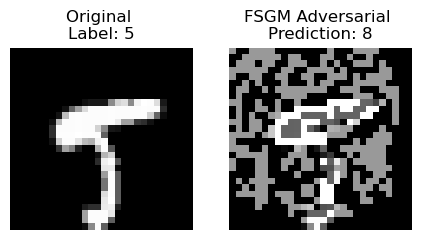

Image I: Index 1518. Label 2
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


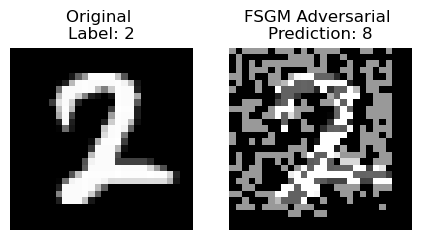

Image I: Index 7881. Label 1
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


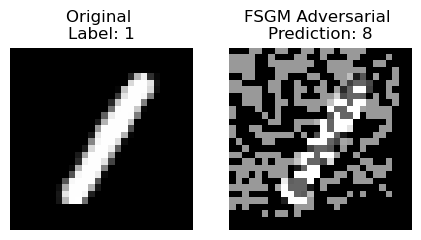

Image I: Index 9603. Label 2
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


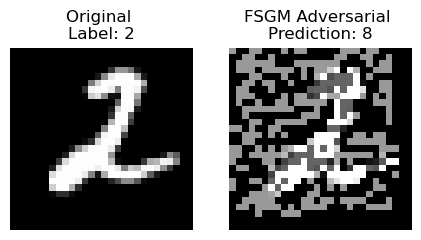

Image I: Index 5075. Label 8
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 5


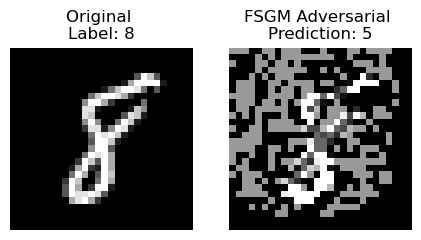

Image I: Index 5813. Label 9
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


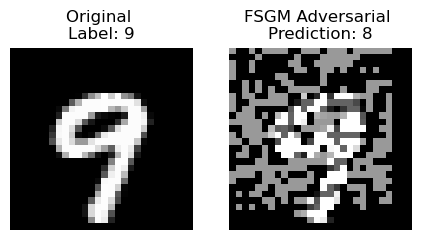

In [234]:
epsilon = 0.6
random.seed(90)


number_of_i_images = 7
for _ in range(number_of_i_images):
            
    j = random.choice(range(len(x_test_mnist_scaled)))
    test_image_i_label = y_test_mnist[j] 

    # We ensure that they are different
    if test_image_i_label == test_image_t_label:
        continue

    test_image_i = x_test_mnist_scaled[j]

    image_index_i = j

    plt.figure(figsize=(8, 3))
    number_of_figure_rows = 1
    number_of_figure_columns = 3
    
    print(f'Image I: Index {j}. Label {test_image_i_label}')

    # Brute black bock attack
    plt.subplot(number_of_figure_rows, number_of_figure_columns, 1)
    plt.imshow(test_image_i, cmap="gray")
    plt.title(f"Original \nLabel: {test_image_i_label}")
    plt.axis("off")


    # Fast sign gradient method
    adversarial_prediction, fsgm_adversarial_tensor = fast_gradient_sign_method(image_index_i, epsilon, best_mnist_model, x_test_mnist_scaled, y_test_mnist)

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 2)
    plt.imshow(fsgm_adversarial_tensor[0, :, :, 0], cmap="gray")
    plt.title(f"FSGM Adversarial \nPrediction: {adversarial_prediction}")
    plt.axis("off")


    """plt.subplot(number_of_figure_rows, number_of_figure_columns, 3)
    plt.imshow(fsgm_adversarial_tensor[0, :, :, 0] - test_image_i, cmap="gray")
    plt.title("FSGM Perturbation")
    plt.axis("off")"""

    plt.show()

# Exercise 4.5

Finally, we put everything together by plotting all the results together. Since the plots have already been shown in the previous sections, this part is just about putting the previous code together.

Image I: Index 1518. Label 2
Image T: Index 3336. Label 5
Brute-force Black-box attack:
    Misclassification after 5 changes of 5% pixels each. Prediction: 8
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 15 tweaks of 5% pixels each:
    Probability of being classified as I: 0.43
    Probability of being classified as T: 0.16
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


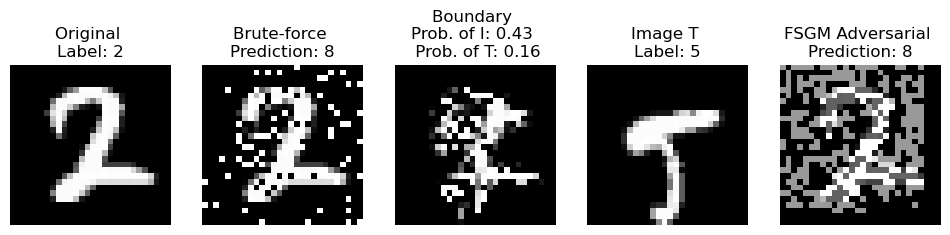

Image I: Index 9414. Label 0
Image T: Index 7881. Label 1
Brute-force Black-box attack:
    Misclassification after 5 changes of 5% pixels each. Prediction: 2
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 7 tweaks of 5% pixels each:
    Probability of being classified as I: 0.34
    Probability of being classified as T: 0.01
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


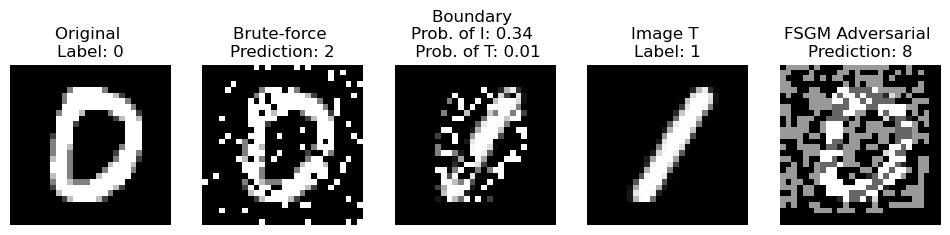

Image I: Index 5075. Label 8
Image T: Index 9603. Label 2
Brute-force Black-box attack:
    Misclassification after 6 changes of 5% pixels each. Prediction: 3
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 14 tweaks of 5% pixels each:
    Probability of being classified as I: 0.56
    Probability of being classified as T: 0.44
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 5


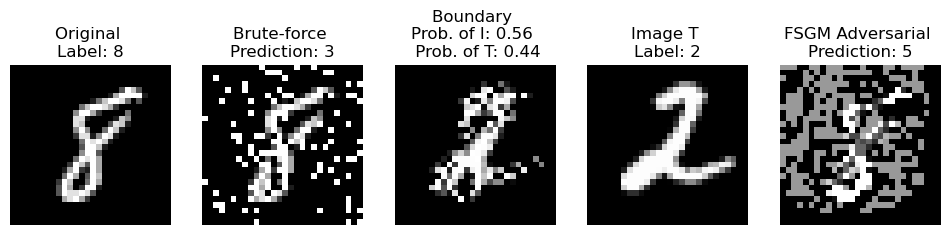

Image I: Index 7393. Label 5
Image T: Index 5813. Label 9
Brute-force Black-box attack:
    Misclassification after 4 changes of 5% pixels each. Prediction: 3
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 10 tweaks of 5% pixels each:
    Probability of being classified as I: 0.51
    Probability of being classified as T: 0.49
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


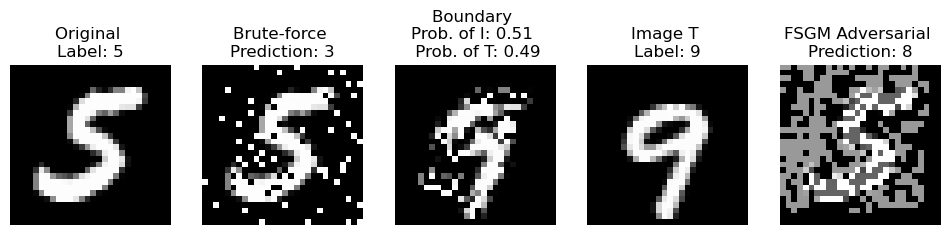

Image I: Index 8001. Label 9
Image T: Index 4337. Label 1
Brute-force Black-box attack:
    Misclassification after 4 changes of 5% pixels each. Prediction: 3
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 7 tweaks of 5% pixels each:
    Probability of being classified as I: 0.47
    Probability of being classified as T: 0.00
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


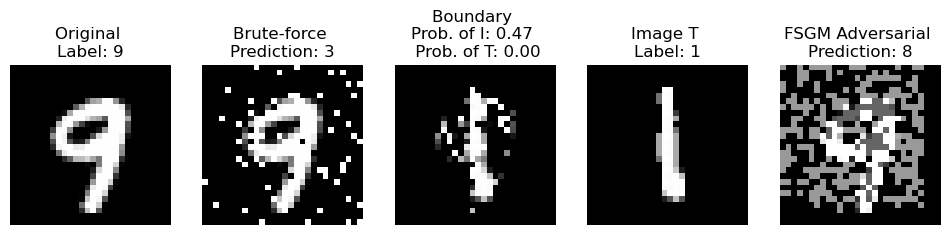

Image I: Index 6058. Label 1
Image T: Index 4470. Label 0
Brute-force Black-box attack:
    Misclassification after 2 changes of 5% pixels each. Prediction: 4
Boundary attack:
    Initial probability of I classified as I: 1.00.
    After 17 tweaks of 5% pixels each:
    Probability of being classified as I: 0.31
    Probability of being classified as T: 0.15
FSGM attack:
    Misclassification obtained with epsilon=0.6. Prediction: 8


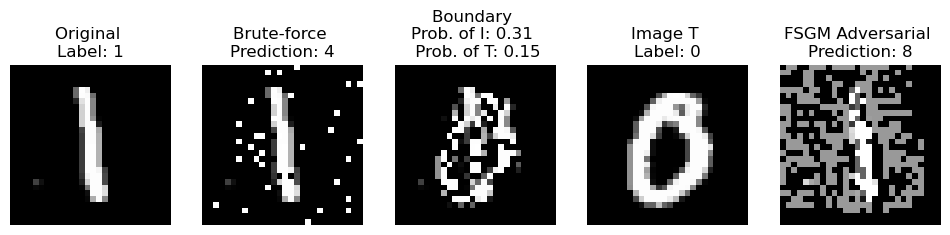

In [235]:

random.seed(90)
rng = random.Random(99)
fraction_of_pixels_changed = 5/100
maximum_number_of_changes = 20

fraction_of_different_pixels_change = 5/100
maximum_number_of_tweaks = 100

epsilon = 0.6



number_of_i_images = 7
for _ in range(number_of_i_images):
            
    i = random.choice(range(len(x_test_mnist_scaled)))
    j = random.choice(range(len(x_test_mnist_scaled)))

    test_image_t_label = y_test_mnist[i] 
    test_image_i_label = y_test_mnist[j] 

    # We ensure that they are different
    if test_image_i_label == test_image_t_label:
        continue

    test_image_t = x_test_mnist_scaled[i]
    test_image_i = x_test_mnist_scaled[j]

    image_index_t = i
    image_index_i = j

    plt.figure(figsize=(12, 6))
    number_of_figure_rows = 1
    number_of_figure_columns = 5
    
    print(f'Image I: Index {j}. Label {test_image_i_label}')
    print(f'Image T: Index {i}. Label {test_image_t_label}')

    # Brute black bock attack
    plt.subplot(number_of_figure_rows, number_of_figure_columns, 1)
    plt.imshow(test_image_i, cmap="gray")
    plt.title(f"Original \nLabel: {test_image_i_label}")
    plt.axis("off")

    rng = random.Random(99)
    j_brute, brute_predicted_label, final_image_i_brute = brute_force_black_box_attack(image_index_i, maximum_number_of_changes, fraction_of_pixels_changed, best_mnist_model, x_test_mnist_scaled, y_test_mnist, rng)
    
    plt.subplot(number_of_figure_rows, number_of_figure_columns, 2)
    plt.imshow(final_image_i_brute, cmap="gray")
    plt.title(f"Brute-force \nPrediction: {brute_predicted_label}") # \n At most {j_brute+1} changes of {fraction_of_pixels_changed*100:.0f}% pixels each.")
    plt.axis("off")
    
    
    # Boundary attack
    rng = random.Random(99)
    j_boundary, final_image_i_boundary, final_probability_of_class_i, final_probability_of_class_t = boundary_black_box_attack(image_index_i, image_index_t, fraction_of_different_pixels_change, maximum_number_of_tweaks, best_mnist_model, x_test_mnist_scaled, y_test_mnist, rng)

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 3)
    plt.imshow(final_image_i_boundary, cmap="gray")
    plt.title(f"Boundary \nProb. of I: {final_probability_of_class_i:.2f} \n Prob. of T: {final_probability_of_class_t:.2f}")
    plt.axis("off")

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 4)
    plt.imshow(test_image_t, cmap="gray")
    plt.title(f"Image T \nLabel: {test_image_t_label}")
    plt.axis("off")


    # Fast sign gradient method
    adversarial_prediction, fsgm_adversarial_tensor = fast_gradient_sign_method(image_index_i, epsilon, best_mnist_model, x_test_mnist_scaled, y_test_mnist)

    plt.subplot(number_of_figure_rows, number_of_figure_columns, 5)
    plt.imshow(fsgm_adversarial_tensor[0, :, :, 0], cmap="gray")
    plt.title(f"FSGM Adversarial \nPrediction: {adversarial_prediction}")
    plt.axis("off")


    """plt.subplot(number_of_figure_rows, number_of_figure_columns, 6)
    plt.imshow(fsgm_adversarial_tensor[0, :, :, 0] - test_image_i, cmap="gray")
    plt.title("FSGM Perturbation")
    plt.axis("off")"""

    plt.show()

## Discussion

After having performed 3 types of adversarial attacks, interesting conclusions can be drawn.
- Although the MNIST data set is huge, it is interesting to note the inability of the model to detect that the number is still the same number after only a few tweaks. For example, the last figure from the previous cell shows an image labeled as a number 1 that with a small amount of noise-pepper noise, the model already classifies as 4; while most humans will surely consider that it is still a 1. This shows the lack of 'flexibility' that the model presents.

- With respect to the FSGM attack, a similar behavior can be observed. Although a noise of 'magnitude' $\epsilon$ is applied, a human would still label all those images using the same label as the original image; however, the model labels them most of the times as a number 8.

- Personally, I have found the boundary attack to be the most interesting of them all. With this model, the question 'what are the actual features that characterize each number?'. For example, in the second image from the previous cell (image I: 2, image T: 8), one is no longer able to determine whether the number is still a 2, or it should be considered as an 8 (even though the model assigns more probability to it being a 2). This type of attack also seems useful to determine the similarities between different numbers: for an image I labeled as 9, and an image T labeled as 1, it is going to be significantly more difficult to make the 9 be misclassified; than the other way around. 

- Another approach that I would like to study in a different project would be to measure how a boundary attack from image $I$ towards a certain label $T_1$ may actually lead to a higher chance of the model classifying it as $T_2$ than as $T_1$. This could indicate a 'high correlation' between classes $T_1$ and $T_2$ without even doing an adversarial attack between an image classified as $T_1$ and one classified as $T_2$.

- Although the results from adversarial attacks can indicate that some changes should be made in the model, they could be extremely benefitial for studying how 'complete' is our training set. Imagine that we have tried different model architectures, but we keep misclassifying certain images after subtle modifications are applied. In those cases, the results may indicate that more training data should be included leading to a higher 'flexibility'.